In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [59]:
chennai = pd.read_csv('chennai_reservoir_levels.csv')
chennai

,Date,POONDI,CHOLAVARAM,REDHILLS,CHEMBARAMBAKKAM
0,01-01-2004,3.9,0.0,268.0,0.0
1,02-01-2004,3.9,0.0,268.0,0.0
2,03-01-2004,3.9,0.0,267.0,0.0
3,04-01-2004,3.9,0.0,267.0,0.0
4,05-01-2004,3.8,0.0,267.0,0.0
...,...,...,...,...,...
5642,13-06-2019,30.0,0.0,0.0,1.0
5643,14-06-2019,28.0,0.0,0.0,1.0
5644,15-06-2019,27.0,0.0,0.0,1.0
5645,16-06-2019,26.0,0.0,0.0,1.0


In [60]:
chennai.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5647 entries, 0 to 5646
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             5647 non-null   object 
 1   POONDI           5647 non-null   float64
 2   CHOLAVARAM       5647 non-null   float64
 3   REDHILLS         5647 non-null   float64
 4   CHEMBARAMBAKKAM  5647 non-null   float64
dtypes: float64(4), object(1)
memory usage: 220.7+ KB


In [61]:
chennai['Date'] = pd.to_datetime(chennai['Date'],format='%d-%m-%Y')
chennai.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5647 entries, 0 to 5646
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             5647 non-null   datetime64[ns]
 1   POONDI           5647 non-null   float64       
 2   CHOLAVARAM       5647 non-null   float64       
 3   REDHILLS         5647 non-null   float64       
 4   CHEMBARAMBAKKAM  5647 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 220.7 KB


In [62]:
demo_ts = pd.to_datetime('13-02-2050',format='%d-%m-%Y')
type(demo_ts)

pandas._libs.tslibs.timestamps.Timestamp

In [63]:
demo_ts.year

2050

In [64]:
demo_ts.day_of_week

6

In [65]:
chennai['Year'] = chennai['Date'].apply(lambda x : x.year)
chennai['Month'] = chennai['Date'].apply(lambda x : x.month)


In [66]:
chennai.columns

Index(['Date', 'POONDI', 'CHOLAVARAM', 'REDHILLS', 'CHEMBARAMBAKKAM', 'Year',
       'Month'],
      dtype='object')

In [67]:
chennai['Total'] = chennai[['POONDI', 'CHOLAVARAM', 'REDHILLS', 'CHEMBARAMBAKKAM']].sum(axis=1)
chennai

,Date,POONDI,CHOLAVARAM,REDHILLS,CHEMBARAMBAKKAM,Year,Month,Total
0,2004-01-01,3.9,0.0,268.0,0.0,2004,1,271.9
1,2004-01-02,3.9,0.0,268.0,0.0,2004,1,271.9
2,2004-01-03,3.9,0.0,267.0,0.0,2004,1,270.9
3,2004-01-04,3.9,0.0,267.0,0.0,2004,1,270.9
4,2004-01-05,3.8,0.0,267.0,0.0,2004,1,270.8
...,...,...,...,...,...,...,...,...
5642,2019-06-13,30.0,0.0,0.0,1.0,2019,6,31.0
5643,2019-06-14,28.0,0.0,0.0,1.0,2019,6,29.0
5644,2019-06-15,27.0,0.0,0.0,1.0,2019,6,28.0
5645,2019-06-16,26.0,0.0,0.0,1.0,2019,6,27.0


In [68]:
YearWise = chennai.groupby('Year', as_index=False).mean()[['Year',
                            'POONDI','CHOLAVARAM','REDHILLS','CHEMBARAMBAKKAM','Total']]
YearWise

,Year,POONDI,CHOLAVARAM,REDHILLS,CHEMBARAMBAKKAM,Total
0,2004,77.766967,19.060109,220.899180,68.683060,386.409317
1,2005,722.680603,147.771781,1468.480712,581.345205,2920.278301
2,2006,1827.553425,484.947945,2044.356164,2075.317808,6432.175342
3,2007,1794.912329,286.391781,2356.654795,1715.126027,6153.084932
4,2008,1862.338798,545.609290,2445.161202,2196.967213,7050.076503
5,2009,1846.221918,414.882110,1969.731205,1795.677123,6026.512356
6,2010,1651.523288,382.175342,2045.271233,2020.501370,6099.471233
7,2011,2399.068493,499.509589,2573.326027,2492.282192,7964.186301
8,2012,1742.816940,225.934426,1872.218579,1571.677596,5412.647541
9,2013,536.953425,100.049315,1324.109589,988.964384,2950.076712


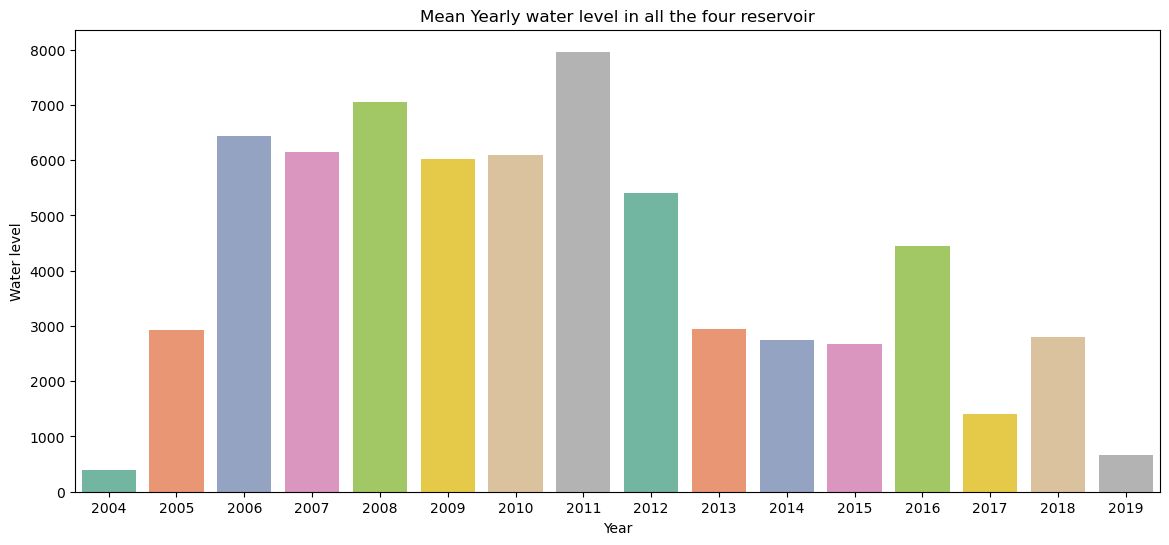

In [69]:
plt.figure(figsize=(14,6))
sns.barplot(x='Year',y='Total',data=YearWise, palette='Set2')
plt.title('Mean Yearly water level in all the four reservoir')
plt.ylabel('Water level')
plt.xlabel('Year')

plt.show()

In [70]:
YearWise.columns

Index(['Year', 'POONDI', 'CHOLAVARAM', 'REDHILLS', 'CHEMBARAMBAKKAM', 'Total'], dtype='object')

<Axes: xlabel='Year'>

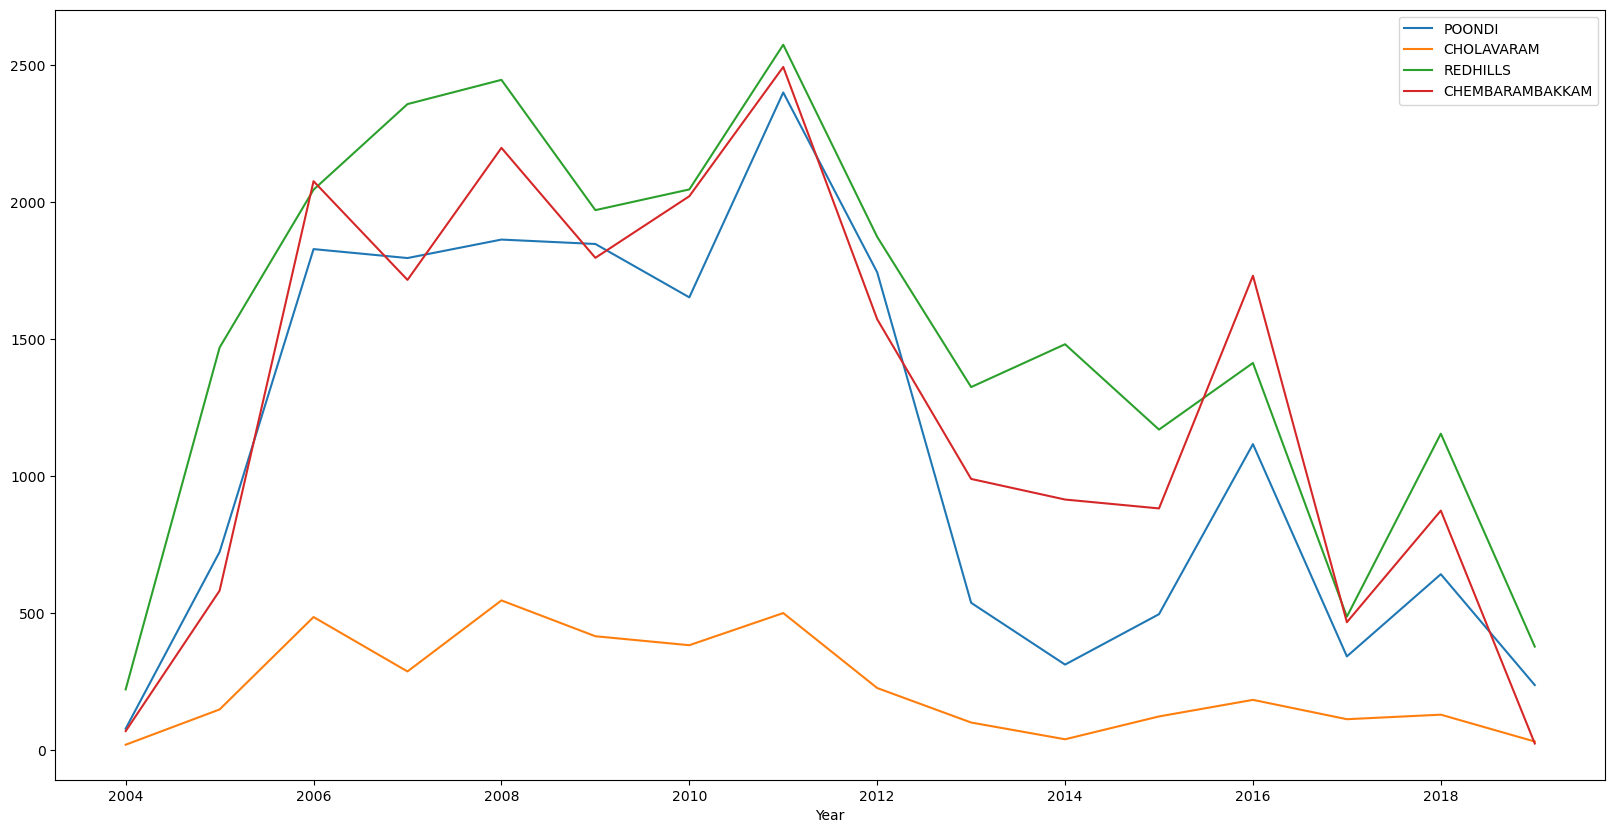

In [71]:
YearWise.plot(x='Year', y = ['POONDI', 'CHOLAVARAM', 'REDHILLS', 'CHEMBARAMBAKKAM'], figsize=(20,10))

<Axes: xlabel='Year', ylabel='Total'>

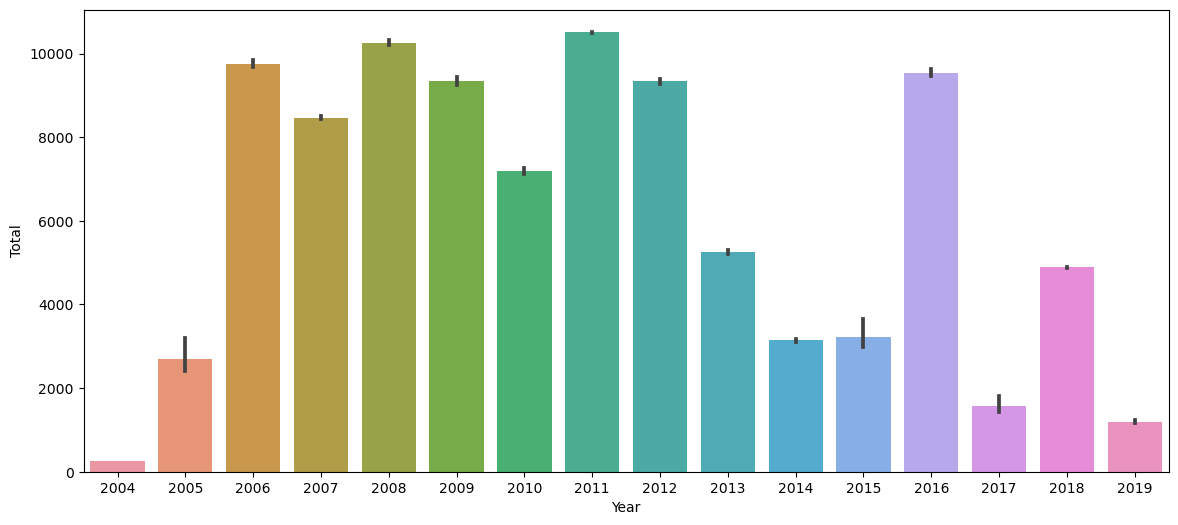

In [72]:
jan = chennai[chennai['Month']==1]
plt.figure(figsize=(14,6))
sns.barplot(x='Year',y='Total',data=jan)

<Axes: xlabel='Month', ylabel='Total'>

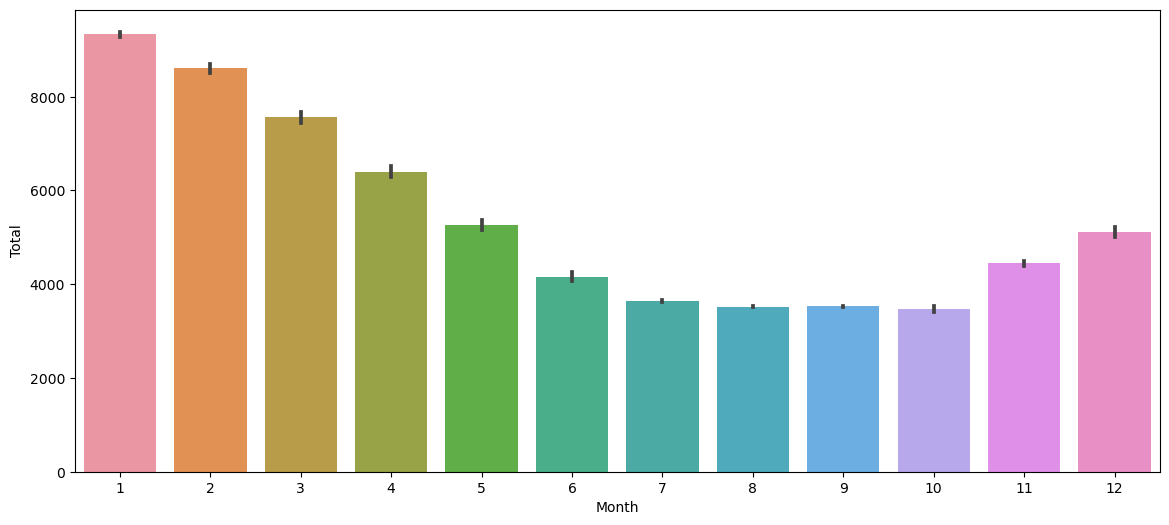

In [73]:
yr2014 = chennai[chennai['Year']==2012]
plt.figure(figsize=(14,6))
sns.barplot(x='Month',y='Total',data=yr2014)

In [78]:
chennai['Month'] = pd.Categorical(chennai['Month'])
chennai['Year'] = chennai['Year'].astype('category')

In [81]:
chennai['Month_name'] = chennai['Date'].apply(lambda x : x.month_name())


/Users/shrey/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/shrey/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


<Axes: xlabel='Year', ylabel='Total'>

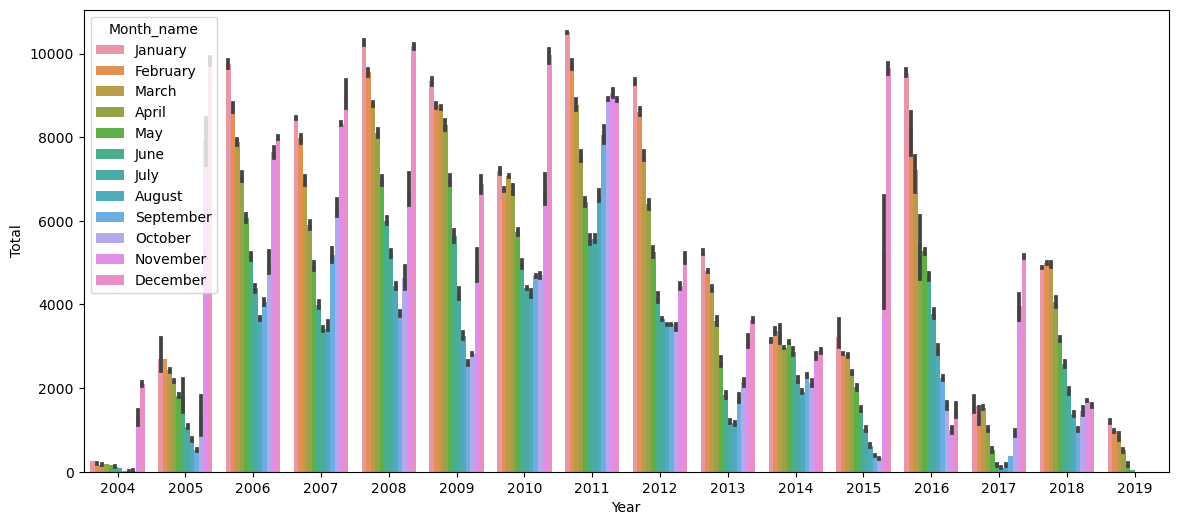

In [84]:
plt.figure(figsize=(14,6))
sns.barplot(x='Year', y = 'Total', data = chennai, hue = "Month_name")

###### Inferences :- 

1. Althought chennai receive some rainfall in July, Aug, Sep due to SW monsoon but majority of rainfall happens in Oct to Dec.

2. From 2006 to 2010, NE monsoon has much more contribution than SW monsoon

3. But in last few years, both SW and NE are contributing qually or SW is contributing much more than NE

4. Declining NE monsoon in recent year is in line with general concern of declining water level in 4 reservoirs in corresponding period. 